# Tensors: The Foundation of Deep Learning

**Author:** Phabel Antonio López Delgado, BSc.

This notebook introduces **tensors**, the fundamental data structure used in deep learning frameworks such as PyTorch and TensorFlow. Tensors are multi‑dimensional arrays that represent numerical data. We explore tensor ranks, shapes, operations, and properties using NumPy, PyTorch, and TensorFlow.

**Key Concepts Covered:**
- Tensor rank (scalar, vector, matrix, higher‑order tensors).
- Tensor dimensions and shapes.
- Creating and manipulating tensors.
- Accessing tensor elements.
- Reshaping tensors.
- Data types in PyTorch.
- Gradients and automatic differentiation (`requires_grad`).
- GPU acceleration with CUDA.

**Key Techniques & Libraries:**
- `numpy` – array creation and manipulation.
- `matplotlib` – 3D vector visualisation.
- `torch` – tensor operations, gradients, GPU support.
- `tensorflow` – tensor creation.

**Objective:**
To understand the structure and properties of tensors, and to become familiar with tensor operations in PyTorch – the foundation for building and training neural networks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("All imports successful.")

All imports successful.


## 1. What is a Tensor?

A **tensor** is a mathematical object that generalises scalars, vectors, and matrices to higher dimensions. In machine learning, tensors are used to represent numerical data in multi‑dimensional arrays.

- **Rank** – the number of indices required to access an element.
- **Shape** – the size of each dimension.

| Rank | Name     | Notation      |
|------|----------|---------------|
| 0    | Scalar   | λ             |
| 1    | Vector   | xᵢ            |
| 2    | Matrix   | Aᵢⱼ           |
| 3    | Tensor   | Tᵢⱼₖ          |

## 2. Tensors in NumPy

NumPy provides the `np.array()` function to create tensors of different ranks.

In [2]:
# Rank 1 tensor (vector)
x = np.array([2, 3, 3])
print("Vector x:", x)
print("Shape:", x.shape)
print("Rank:", x.ndim)

Vector x: [2 3 3]
Shape: (3,)
Rank: 1


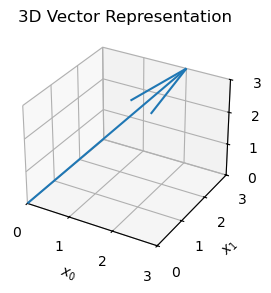

In [3]:
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, x[0], x[1], x[2])
ax.set_xlim([0, 3])
ax.set_ylim([0, 3])
ax.set_zlim([0, 3])
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_zlabel('$x_2$')
plt.title("3D Vector Representation")
plt.show()

### Rank 2 Tensor: Matrix

A matrix is a rank‑2 tensor with two indices: rows and columns.

In [4]:
A = np.array([[0, 5, 1],
              [3, 0, 2],
              [0, 2, 0]])
print("Matrix A:\n", A)
print("Shape:", A.shape)
print("Rank:", A.ndim)

Matrix A:
 [[0 5 1]
 [3 0 2]
 [0 2 0]]
Shape: (3, 3)
Rank: 2


### Higher‑Rank Tensors

Tensors of rank 3 or higher contain multiple matrices stacked together. For example, a rank‑3 tensor can be visualised as a list of matrices.

In [5]:
T = np.array([
    [[0, 5, 1], [3, 0, 2], [0, 2, 0]],
    [[2, 1, 10], [5, 4, 9], [1, 0, 0.5]]
])
print("Tensor T (rank 3):\n", T)
print("Shape:", T.shape)
print("Rank:", T.ndim)

Tensor T (rank 3):
 [[[ 0.   5.   1. ]
  [ 3.   0.   2. ]
  [ 0.   2.   0. ]]

 [[ 2.   1.  10. ]
  [ 5.   4.   9. ]
  [ 1.   0.   0.5]]]
Shape: (2, 3, 3)
Rank: 3


## 3. Tensors in PyTorch and TensorFlow

Deep learning frameworks like PyTorch and TensorFlow provide tensor objects with GPU acceleration and automatic differentiation.

### Creating Tensors

In [6]:
# PyTorch
x_torch = torch.tensor([2, 3, 3])
A_torch = torch.tensor([[0, 5, 1], [3, 0, 2], [0, 2, 0]])
T_torch = torch.tensor([
    [[0, 5, 1], [3, 0, 2], [0, 2, 0]],
    [[2, 1, 10], [5, 4, 9], [1, 0, 0.5]]
])

# TensorFlow
x_tf = tf.constant([2, 3, 3])
A_tf = tf.constant([[0, 5, 1], [3, 0, 2], [0, 2, 0]])
T_tf = tf.constant([
    [[[0, 5, 1], [3, 0, 2], [0, 2, 0]],
     [[2, 1, 10], [5, 4, 9], [1, 0, 0.5]]],
    [[[0, 5, 1], [3, 0, 2], [0, 2, 0]],
     [[2, 1, 10], [5, 4, 9], [1, 0, 0.5]]]
])

print("PyTorch tensor:\n", x_torch)
print("TensorFlow tensor:\n", x_tf)

PyTorch tensor:
 tensor([2, 3, 3])
TensorFlow tensor:
 tf.Tensor([2 3 3], shape=(3,), dtype=int32)


## 4. Tensor Dimensions (Shape)

The shape of a tensor tells us how many elements it contains along each dimension. We can access the shape using:

- `numpy`: `T.shape`
- `PyTorch`: `T.shape` or `T.size()`
- `TensorFlow`: `T.shape`

In [7]:
print(f"Vector x has shape: {x_torch.shape} (size: {x_torch.size()})")
print(f"Matrix A has shape: {A_torch.shape}")
print(f"Tensor T has shape: {T_torch.shape}")

Vector x has shape: torch.Size([3]) (size: torch.Size([3]))
Matrix A has shape: torch.Size([3, 3])
Tensor T has shape: torch.Size([2, 3, 3])


## 5. Accessing Tensor Elements

We can access specific elements using indexing: `tensor[i1, i2, ..., in]`.

In [8]:
# Access entire second column of A
print("A[:, 1]:", A_torch[:, 1])

# Access first slice of T
print("T[:, :, 0]:\n", T_torch[:, :, 0])

A[:, 1]: tensor([5, 0, 2])
T[:, :, 0]:
 tensor([[0., 3., 0.],
        [2., 5., 1.]])


## 6. Reshaping Tensors

PyTorch provides two methods to reshape tensors:

- `view()` – uses the same memory (fast, but requires contiguous memory).
- `reshape()` – creates a new tensor (more flexible).

In [9]:
# Reshape T (2x3x3) to (2x9)
T_reshaped_view = T_torch.view(2, 9)
print("T reshaped with view:\n", T_reshaped_view)

# Reshape A (3x3) to (9,)
A_reshaped = A_torch.reshape(9)
print("A reshaped to vector:\n", A_reshaped)

T reshaped with view:
 tensor([[ 0.0000,  5.0000,  1.0000,  3.0000,  0.0000,  2.0000,  0.0000,  2.0000,
          0.0000],
        [ 2.0000,  1.0000, 10.0000,  5.0000,  4.0000,  9.0000,  1.0000,  0.0000,
          0.5000]])
A reshaped to vector:
 tensor([0, 5, 1, 3, 0, 2, 0, 2, 0])


## 7. Data Types in PyTorch

PyTorch supports various data types:

| Data Type        | PyTorch Type      |
|------------------|-------------------|
| Boolean          | `BoolTensor`      |
| 32‑bit float     | `FloatTensor`     |
| 64‑bit float     | `DoubleTensor`    |
| 16‑bit float     | `HalfTensor`      |
| 8‑bit integer    | `CharTensor`      |
| 16‑bit integer   | `ShortTensor`     |
| 32‑bit integer   | `IntTensor`       |
| 64‑bit integer   | `LongTensor`      |

In [11]:
# Creating tensors with specific types
bool_tensor = torch.BoolTensor([0, 1])
half_tensor = torch.HalfTensor([0, 1])
long_tensor = torch.LongTensor([0, 1])
float_tensor = torch.FloatTensor([0, 1])

print("BoolTensor:", bool_tensor)
print("HalfTensor:", half_tensor)
print("LongTensor:", long_tensor)
print("FloatTensor:", float_tensor)

# Specifying dtype during creation
a = torch.tensor([0, 1], dtype=torch.float32)
print("Specified dtype:", a)

BoolTensor: tensor([False,  True])
HalfTensor: tensor([0., 1.], dtype=torch.float16)
LongTensor: tensor([0, 1])
FloatTensor: tensor([0., 1.])
Specified dtype: tensor([0., 1.])


## 8. Gradients and Automatic Differentiation

A key feature of PyTorch is automatic differentiation. By setting `requires_grad=True`, PyTorch tracks operations on a tensor so that gradients can be computed via backpropagation.

In [12]:
# Create a tensor that requires gradients
x = torch.FloatTensor([1, 3]).requires_grad_(True)
print("x:", x)

# Perform operations
result1 = x.pow(2)
result = result1.sum()
print("x^2:", result1)
print("Sum:", result)

# Compute gradients
result.backward()
print("Gradient of x (d/dx):", x.grad)

x: tensor([1., 3.], requires_grad=True)
x^2: tensor([1., 9.], grad_fn=<PowBackward0>)
Sum: tensor(10., grad_fn=<SumBackward0>)
Gradient of x (d/dx): tensor([2., 6.])


In [14]:
# Important: Gradients accumulate by default
# Reset gradients to zero before computing new ones
x.grad.zero_()

a = torch.FloatTensor([5, 4])
result = torch.dot(a, x)
result.backward()
print("Gradient after dot product (a):", x.grad)

Gradient after dot product (a): tensor([5., 4.])


## 9. GPU Support with CUDA

PyTorch can move tensors to GPU memory for faster computation using `.to(device)`.

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Move tensor to GPU if available
x_gpu = x.to(device)
print("Tensor on GPU:", x_gpu)

# Move back to CPU if needed
x_cpu = x.cpu()
print("Tensor on CPU:", x_cpu)

Using device: cpu
Tensor on GPU: tensor([1., 3.], requires_grad=True)
Tensor on CPU: tensor([1., 3.], requires_grad=True)


## Summary and Next Steps

**Accomplished:**
- Defined tensors and their rank/shape.
- Created tensors using NumPy, PyTorch, and TensorFlow.
- Visualised a 3D vector.
- Explored tensor shapes and element access.
- Reshaped tensors using `view()` and `reshape()`.
- Learned about PyTorch data types.
- Used `requires_grad` for automatic differentiation.
- Moved tensors to GPU for accelerated computation.

**Key Insights:**
- Tensors are the fundamental data structure in deep learning.
- Rank indicates the number of indices (scalar: 0, vector: 1, matrix: 2, etc.).
- Shape defines the size of each dimension.
- PyTorch provides powerful tensor operations with GPU support and automatic differentiation.
- `requires_grad` enables gradient computation for optimisation.
- Gradients accumulate by default – remember to zero them when needed.

**Suggested Next Steps:**
1. **Practice creating tensors** – experiment with different ranks and shapes.
2. **Explore tensor operations** – addition, multiplication, broadcasting.
3. **Work with real data** – convert NumPy arrays to PyTorch tensors.
4. **Build a simple computational graph** – combine tensors and gradients.

**Reflection:**
This notebook provides a solid foundation in tensor manipulation, which is essential for building neural networks. Understanding tensors, their properties, and operations is the first step towards mastering PyTorch and deep learning.